In [4]:
import os
import re
import json
import gc

import numpy as np
import pandas as pd
from Bio.PDB import PDBParser, PPBuilder
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from tqdm import tqdm

gc.collect()

0

In [ ]:
# Data path
DATA_PATH = r"C:\ZHAW\PA2\data\PDBbind_v2021_by_2020"

# List all files and directories
for dirpath, dirnames, filenames in os.walk(DATA_PATH):
    print(f"Current folder: {dirpath}")
    print("Subfolders:", dirnames)
    print("Files:", filenames)

In [ ]:
# ---------- Helper Functions ----------

def pdb_to_sequence(pdb_file):
    """Convert a PDB file to amino acid sequence(s)"""
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("protein", pdb_file)
    ppb = PPBuilder()
    seqs = [str(pp.get_sequence()) for pp in ppb.build_peptides(structure)]
    return seqs

def mol2_to_smiles(mol2_file):
    """Convert MOL2 to a SMILES string"""
    try:
        mol = Chem.MolFromMol2File(mol2_file, sanitize=True)
        if mol:
            return Chem.MolToSmiles(mol)
    except Exception as e:
        pass
    return None

def sdf_to_smiles(sdf_file):
    """Convert SDF file (may contain multiple molecules) to list of SMILES"""
    try:
        supplier = Chem.SDMolSupplier(sdf_file)
        smiles_list = []
        for mol in supplier:
            if mol:
                smiles_list.append(Chem.MolToSmiles(mol))
        return smiles_list
    except Exception as e:
        return []

def process_complex(complex_folder):
    """Process one PDBbind subfolder: extract protein + pocket sequences + ligand SMILES"""
    pdb_id = os.path.basename(complex_folder)

    # --- Protein sequence ---
    protein_file = next((f for f in os.listdir(complex_folder) if f.endswith("_protein.pdb")), None)
    sequences = pdb_to_sequence(os.path.join(complex_folder, protein_file)) if protein_file else []

    # --- Pocket sequence ---
    pocket_file = next((f for f in os.listdir(complex_folder) if f.endswith("_pocket.pdb")), None)
    pocket_sequences = pdb_to_sequence(os.path.join(complex_folder, pocket_file)) if pocket_file else []

    # --- Ligand SMILES ---
    ligand_files = [f for f in os.listdir(complex_folder) if f.endswith(".mol2") or f.endswith(".sdf")]
    smiles_list = []
    for ligand_file in ligand_files:
        path = os.path.join(complex_folder, ligand_file)
        if ligand_file.endswith(".mol2"):
            smi = mol2_to_smiles(path)
            if smi:
                smiles_list.append(smi)
        elif ligand_file.endswith(".sdf"):
            smiles_list.extend(sdf_to_smiles(path))

    return {
        "pdb_id": pdb_id,
        "protein_sequences": sequences,
        "pocket_sequences": pocket_sequences,
        "ligand_smiles": smiles_list
    }

# ---------- DATA_PATH ----------
root = DATA_PATH
subfolders = [os.path.join(root, d) for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]

#  Process all complexes 
results = []
for folder in tqdm(subfolders, desc="Processing complexes"):
    results.append(process_complex(folder))

# Save CSV 
rows = []
for entry in results:
    pdb_id = entry["pdb_id"]
    protein_sequences = entry["protein_sequences"]
    pocket_sequences = entry["pocket_sequences"]
    smiles_list = entry["ligand_smiles"]

    if smiles_list:
        for smi in smiles_list:
            rows.append({
                "pdb_id": pdb_id,
                "protein_sequences": protein_sequences,
                "pocket_sequences": pocket_sequences,
                "ligand_smiles": smi
            })
    else:
        rows.append({
            "pdb_id": pdb_id,
            "protein_sequences": protein_sequences,
            "pocket_sequences": pocket_sequences,
            "ligand_smiles": None
        })

df = pd.DataFrame(rows)
df.to_csv("PDBbind_protein_pocket_ligands.csv", index=False)
print("Saved CSV with protein sequences, pocket sequences, and ligand SMILES!")

Processing complexes: 100%|██████████| 19061/19061 [1:03:27<00:00,  5.01it/s]


Saved CSV with protein sequences, pocket sequences, and ligand SMILES!


## **Data Preprocessing**

In [ ]:
# Load and clean PDBbind_protein_pocket_ligands.csv
df = pd.read_csv("PDBbind_protein_pocket_ligands.csv")
df = df.dropna() # Delete rows with NA
df

,pdb_id,protein_sequences,pocket_sequences,ligand_smiles
0,10gs,['PYTVVYFPVRGRCAALRMLLADQGQSWKEEVVTVETWQEGSLKA...,"['VYFPVRGRCAALR', 'VVTVETWQEG', 'LKA', 'CLYGQL...",[NH3+][C@@H](CCC(=O)N[C@@H](CSCc1ccccc1)C(=O)N...
1,10gs,['PYTVVYFPVRGRCAALRMLLADQGQSWKEEVVTVETWQEGSLKA...,"['VYFPVRGRCAALR', 'VVTVETWQEG', 'LKA', 'CLYGQL...",[NH3+][C@@H](CCC(=O)N[C@@H](CSCc1ccccc1)C(=O)N...
2,11gs,['PYTVVYFPVRGRCAALRMLLADQGQSWKEEVVTVETWQEGSLKA...,"['VYFPVRGRCAALR', 'VVTVETWQEG', 'LKA', 'CLYGQL...",CC[C@@H](CSC[C@H](NC(=O)CC[C@H]([NH3+])C(=O)[O...
3,11gs,['PYTVVYFPVRGRCAALRMLLADQGQSWKEEVVTVETWQEGSLKA...,"['VYFPVRGRCAALR', 'VVTVETWQEG', 'LKA', 'CLYGQL...",CC[C@@H](CSC[C@H](NC(=O)CC[C@H]([NH3+])C(=O)[O...
4,13gs,['MPPYTVVYFPVRGRCAALRMLLADQGQSWKEEVVTVETWQEGSL...,"['YFPVRGRCAA', 'VVTVETWQE', 'LK', 'QLP', 'QSN'...",O=C([O-])C1=C/C(=N\Nc2ccc(S(=O)(=O)Nc3ccccn3)c...
...,...,...,...,...
37799,9hvp,['PQITLWQRPLVTIKIGGQLKEALLDTGADDTVLEEMNLPGRWKP...,"['RPL', 'ALLDTGADDTVLE', 'KMIGGIGGFIKV', 'VL',...",CC(C)[C@H](NC(=O)OCc1ccccc1)C(=O)N[C@@H](Cc1cc...
37800,9icd,['SKVVVPAQGKKITLQNGKLNVPENPIIPYIEGDGIGVDVTPAML...,"['DGIGVDVT', 'AM', 'GPLTT', 'GGIGIAP', 'EATHGT...",Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])[O-])...
37801,9icd,['SKVVVPAQGKKITLQNGKLNVPENPIIPYIEGDGIGVDVTPAML...,"['DGIGVDVT', 'AM', 'GPLTT', 'GGIGIAP', 'EATHGT...",Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)([O-])[O-])...
37802,9lpr,['ANIVGGIEYSINNASLCSVGFSVTRGATKGFVTAGHCGTVNATA...,"['EYSI', 'SLCSV', 'TAGHCG', 'FPGND', 'RSGRTT',...",CC(C)C[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H](C)NC(...


#### Amino acid - Codes

| 1-Letter | 3-Letter | Name            |
|----------|----------|-----------------|
| A        | Ala      | Alanin          |
| C        | Cys      | Cystein         |
| D        | Asp      | Asparaginsäure  |
| E        | Glu      | Glutaminsäure   |
| F        | Phe      | Phenylalanin    |
| G        | Gly      | Glycin          |
| H        | His      | Histidin        |
| I        | Ile      | Isoleucin       |
| K        | Lys      | Lysin           |
| L        | Leu      | Leucin          |
| M        | Met      | Methionin       |
| N        | Asn      | Asparagin       |
| P        | Pro      | Prolin          |
| Q        | Gln      | Glutamin        |
| R        | Arg      | Arginin         |
| S        | Ser      | Serin           |
| T        | Thr      | Threonin        |
| V        | Val      | Valin           |
| W        | Trp      | Tryptophan      |
| Y        | Tyr      | Tyrosin         |


#### **Load Index and calculate pk - values**

In [16]:
# ---------- Helper Function ----------
def parse_binding(binding_str):
    """
    Parse binding data like 'Ki=540nM', 'Kd=0.010uM', 'Ki<=17nM', 'Ki=3pM'
    and return pK value (float). Returns np.nan if parsing fails.
    """
    if pd.isna(binding_str):
        return np.nan
    
    # Regex to extract sign, value, and unit
    match = re.search(r'([<>]?=?)([\d\.]+)([munp]?M)', binding_str)
    if not match:
        return np.nan
    
    sign, value, unit = match.groups()
    value = float(value)
    
    # Calculate molar concentration
    unit = unit.lower()
    if unit == "mm":  # Millimolar
        molar = value * 1e-3
    elif unit == "um":  # Micromolar
        molar = value * 1e-6
    elif unit == "nm":  # Nanomolar
        molar = value * 1e-9
    elif unit == "pm":  # Picomolar
        molar = value * 1e-12
    else:
        return np.nan
    
    # Calculate pK
    pK = -np.log10(molar)
    
    # If it's a limit (e.g., < or <=), return NaN or handle as needed
    if sign in ["<", "<="]:
        return np.nan  
    
    return pK

# Load and parse INDEX_general_PL.2021_filtered_by_2020 (from uM to pk)
with open("INDEX_general_PL.2021_filtered_by_2020", "r") as f:
    lines = [line.strip() for line in f if not line.startswith("#") and line.strip()]

# Split lines into columns
data = []
for line in lines:
    parts = line.split("//")  # split at //
    main = parts[0].split()   # split main part by whitespace
    
    pdb_id = main[0]
    resolution = main[1]
    year = main[2]
    binding_data = main[3]
    comment = parts[1].strip() if len(parts) > 1 else ""
    
    data.append([pdb_id, resolution, year, binding_data, comment])

# Create DataFrame
df_index = pd.DataFrame(data, columns=["pdb_id", "resolution", "year", "binding_data", "comment"])

# Calculate pK values
df_index["pK"] = df_index["binding_data"].apply(parse_binding)

# Drop rows with NaN pK values
df_index = df_index.dropna(subset=["pK"]).reset_index(drop=True)
df_index

,pdb_id,resolution,year,binding_data,comment,pK
0,2tpi,2.10,1982,Kd=49uM,2tpi.pdf (2-mer),4.309804
1,5tln,2.30,1982,Ki=0.43uM,5tln.pdf (BAN) incomplete ligand structure,6.366532
2,4tln,2.30,1982,Ki=190uM,4tln.pdf (LNO),3.721246
3,6rsa,NMR,1986,Ki=40uM,6rsa.pdf (UVC),4.397940
4,1rnt,1.90,1987,Kd=6.5uM,1rnt.pdf (2GP),5.187087
...,...,...,...,...,...,...
18888,6k04,1.25,2019,Ki=9.1nM,6k04.pdf (CQF) ligand is 40,8.040959
18889,6q8a,2.11,2019,Ki=9.8nM,6hb5.pdf (HQ5) [Incomplete ligand],8.008774
18890,6ic2,1.15,2019,Ki=917.4nM,6ic2.pdf (BBJ) ligand is EPA,6.037441
18891,6gvh,2.74,2019,Ki=920nM,6gvf.pdf (FDH) ligand is 3e,6.036212


### **Options to encode Protein Sequences**

| Method                                          | Description                                                                      | Advantage                                          | Disadvantage                                               |
| ----------------------------------------------- | -------------------------------------------------------------------------------- | -------------------------------------------------- | ---------------------------------------------------------- |
| **One-Hot Encoding**                            | Represents each amino acid as a binary vector of length 20 (A=10000…, C=01000…). | Simple, lossless, preserves exact sequence.        | Very high dimensional, no similarity between amino acids.  |
| **k-mers (n-grams)**                            | Counts frequency of subsequences of length *k* (e.g. 3-mers).                    | Captures local motifs, widely used in sequence ML. | Feature space grows exponentially with *k*.                |
| **Amino Acid Composition (AAC)**                | Calculates frequency of each amino acid in the sequence (20 features).           | Very compact, fast to compute.                     | Loses order information completely.                        |
| **Dipeptide Composition**                       | Frequency of amino acid pairs (20×20 = 400 features).                            | Captures local sequence order.                     | Larger feature space, still ignores long-range order.      |
| **Physicochemical Properties**                  | Maps amino acids to descriptors (hydrophobicity, charge, polarity, etc.).        | Biologically meaningful, interpretable.            | Aggregates info, ignores sequence order.                   |
| **CTD (Composition, Transition, Distribution)** | Summarizes composition and transitions of residues with certain properties.      | Rich handcrafted features, widely studied.         | Order is coarse, not residue-level.                        |
| **Pseudo Amino Acid Composition (PseAAC)**      | Extends AAC with sequence-order correlation factors.                             | Compact, keeps some sequence order info.           | Needs parameter tuning, less straightforward to implement. |


---

### **Options to encode SMILES**
| **Method**                                                                                                                   | **Description**                                            | **Advantages**                                                             | **Disadvantages**                                                                           |
| ---------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------- | -------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------- |
| **Fingerprints (e.g., Morgan/ECFP, MACCS, RDKit FP)**                                                                        | Bit vectors representing presence/absence of substructures | - Widely used and fast<br>- Good for similarity tasks<br>- Easy to compute | - Fixed-size, may lose structural detail<br>- Different FPs can give very different results |
| **Physicochemical Descriptors** (e.g., MW, LogP, HBA, HBD, TPSA, rotatable bonds)                                            | Scalar features summarizing chemical properties            | - Simple, interpretable<br>- Captures global properties                    | - Loses structural detail<br>- Limited expressiveness for ML                                |
| **One-Hot Encoding of SMILES tokens**                                                                                        | SMILES treated as string, each character as a category     | - Simple to implement<br>- Keeps exact sequence                            | - Sparse & high dimensional<br>- Sensitive to SMILES notation (canonicalization needed)     |
| **Graph-based Features** (non-embedding, handcrafted graph descriptors: degree counts, atom/bond counts, adjacency features) | Use chemical graph properties as features                  | - Keeps structural information<br>- Can capture connectivity               | - Requires careful design<br>- More complex than fingerprints                               |
| **n-grams of SMILES** (k-mers of SMILES tokens)                                                                              | Extract substrings of SMILES of length n                   | - Captures local patterns<br>- Similar to text feature extraction          | - Redundant, sensitive to SMILES syntax<br>- Can get very high-dimensional                  |
| **Topological Descriptors** (e.g., Wiener index, Balaban index, eccentric connectivity index)                                | Numerical descriptors based on molecular graph topology    | - Captures global connectivity<br>- Established in chemoinformatics        | - Harder to compute<br>- Not as interpretable as physicochemical descriptors                |

---

### **Encode Protein Sequences** 



In [17]:
# working copy
df_features = df.copy()

# ---- Amino acid alphabet ----
AMINO_ACIDS = list("ACDEFGHIKLMNPQRSTVWY")

# Groups for simple physicochemical mapping
hydrophobic = set("AILMFWYV")
polar = set("STNQ")
charged_pos = set("KRH")
charged_neg = set("DE")
aromatic = set("FYW")

# ---- AAC ----
def compute_aac(seq):
    seq = str(seq).upper()
    length = len(seq)
    if length == 0:
        return {aa: 0 for aa in AMINO_ACIDS}
    return {aa: seq.count(aa) / length for aa in AMINO_ACIDS}

# ---- Dipeptide Composition ----
def compute_dpc(seq):
    seq = str(seq).upper()
    length = len(seq) - 1
    if length <= 0:
        return {f"{a}{b}": 0 for a in AMINO_ACIDS for b in AMINO_ACIDS}
    dpc_counts = {}
    for a in AMINO_ACIDS:
        for b in AMINO_ACIDS:
            pair = a + b
            dpc_counts[pair] = seq.count(pair) / length
    return dpc_counts

# ---- Physicochemical features ----
def compute_physchem(seq):
    seq = str(seq).upper()
    length = len(seq)
    if length == 0:
        return {
            "frac_hydrophobic": 0, "frac_polar": 0, "frac_pos": 0,
            "frac_neg": 0, "frac_aromatic": 0, "avg_mass": 0,
        }
    return {
        "frac_hydrophobic": sum(aa in hydrophobic for aa in seq) / length,
        "frac_polar": sum(aa in polar for aa in seq) / length,
        "frac_pos": sum(aa in charged_pos for aa in seq) / length,
        "frac_neg": sum(aa in charged_neg for aa in seq) / length,
        "frac_aromatic": sum(aa in aromatic for aa in seq) / length,
        "avg_mass": np.mean([110 if aa in AMINO_ACIDS else 0 for aa in seq]),
    }

# Apply on df_features 
df_prot = df_features.copy()

aac_df = df_features["protein_sequences"].apply(compute_aac).apply(pd.Series)
dpc_df = df_features["protein_sequences"].apply(compute_dpc).apply(pd.Series)
prot_physchem_df = df_features["protein_sequences"].apply(compute_physchem).apply(pd.Series)

df_prot_encoded = pd.concat([df_prot, aac_df, dpc_df, prot_physchem_df], axis=1)
print("Protein encoding done:", df_prot_encoded.shape)

Protein encoding done: (37801, 430)


### **Encode SMILES** 

In [ ]:
# ---- Helper Functions ----
def smiles_to_mol(smiles):
    try:
        return Chem.MolFromSmiles(str(smiles))
    except:
        return None

# ---- Morgan Fingerprint (ECFP4, 2048 bits) ----
def mol_to_morgan_fp(mol, radius=2, n_bits=2048):
    if mol is None:
        return [0]*n_bits
    fp = rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
    return list(fp)

# ---- Physicochemical Descriptors ----
def mol_to_physchem(mol):
    if mol is None:
        return {
            "MolWt": 0, "LogP": 0, "NumHDonors": 0,
            "NumHAcceptors": 0, "TPSA": 0, "RotatableBonds": 0,
        }
    return {
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "NumHDonors": Descriptors.NumHDonors(mol),
        "NumHAcceptors": Descriptors.NumHAcceptors(mol),
        "TPSA": Descriptors.TPSA(mol),
        "RotatableBonds": Descriptors.NumRotatableBonds(mol),
    }

# Apply on df_features
df_lig = df_features.copy()

df_features["mol"] = df_features["ligand_smiles"].apply(smiles_to_mol)
df_features["MorganFP"] = df_features["mol"].apply(mol_to_morgan_fp)

fp_df = pd.DataFrame(df_features["MorganFP"].tolist(), columns=[f"FP_{i}" for i in range(2048)])
lig_physchem_df = df_features["mol"].apply(mol_to_physchem).apply(pd.Series)

df_lig_encoded = pd.concat([df_features.drop(columns=["mol","MorganFP"]), fp_df, lig_physchem_df], axis=1)
print("Ligand encoding done:", df_lig_encoded.shape)

In [ ]:
# ==========================================
# Combine Protein + Ligand Features + Binding Data
# ==========================================

# Align indices
df_final = pd.concat([df_prot_encoded, fp_df, lig_physchem_df], axis=1)

# Merge with binding data (pk)
df_merged = df_final.merge(df_index[["pdb_id", "pK"]], on="pdb_id", how="inner")
df_merged.head()

In [25]:
# Save CSV
df_merged.to_csv("PDBbind_protein_pocket_ligands_bindingsites_encoded.csv", index=False)
print("Saved:", df_merged.shape, "PDBbind_protein_pocket_ligands_bindingsites_encoded.csv")

Saved: (37469, 2485) PDBbind_protein_pocket_ligands_bindingsites_encoded.csv


---

### **Train - Test - Split**

In [5]:
# Load encoded data without pocket sequences
drop_cols = ["protein_sequences", "pocket_sequences", "ligand_smiles"]

df_all_encoded = pd.read_csv(
    "PDBbind_protein_pocket_ligands_bindingsites_encoded.csv",)
df_all_encoded = df_all_encoded.drop(columns=drop_cols)
df_all_encoded = df_all_encoded.dropna().reset_index(drop=True)

# Load PDBbind original json and split into train and test sets
with open(r"C:\ZHAW\PA2\Sequence_based_models\PDBbind_original_data_split.json", "r") as file:
    original_data_split = json.load(file)

train_ids = original_data_split["train"]

# Extract test IDs for different CASF sets
test_ids_dict = {
    "casf2013_c5": set(original_data_split.get("casf2013_c5", [])),
    "casf2016_c5": set(original_data_split.get("casf2016_c5", [])),
    "casf2013": set(original_data_split.get("casf2013", [])),
    "casf2016": set(original_data_split.get("casf2016", [])),
}

# Load PDBbind cleansplit json and split into train and test sets
with open(r"C:\ZHAW\PA2\Sequence_based_models\PDBbind_cleansplit_data_split.json", "r") as file:
    cleansplit_data_split = json.load(file)

train_ids_clean = cleansplit_data_split["train"]
test_ids_clean = set()
for key, value in cleansplit_data_split.items():
    if key != "train":
        test_ids_clean.update(value)

print("Original split keys:", original_data_split.keys())
print("Clean split keys:", cleansplit_data_split.keys())

Original split keys: dict_keys(['casf2016', 'casf2013', 'train', 'casf2016_c5', 'casf2013_c5'])
Clean split keys: dict_keys(['casf2016', 'casf2013', 'train', 'casf2016_indep', 'casf2013_indep'])


In [6]:
# Trainingsdata original
train_df_orig = df_all_encoded[df_all_encoded["pdb_id"].isin(train_ids)]
X_train_orig = train_df_orig.drop(columns=["pK", "pdb_id"])
y_train_orig = train_df_orig["pK"]

# Testdata original 
test_datasets = {}
for key, ids in original_data_split.items():
    if key != 'train':  
        test_df = df_all_encoded[df_all_encoded["pdb_id"].isin(ids)]
        X_test = test_df.drop(columns=["pK", "pdb_id"])
        y_test = test_df["pK"]
        test_datasets[key] = (X_test, y_test)

X_test_2013, y_test_2013 = test_datasets["casf2013"]
X_test_2016, y_test_2016 = test_datasets["casf2016"]
X_test_2013_c5, y_test_2013_c5 = test_datasets["casf2013_c5"]
X_test_2016_c5, y_test_2016_c5 = test_datasets["casf2016_c5"]

In [7]:
# Trainingsdata clean
train_df_clean = df_all_encoded[df_all_encoded["pdb_id"].isin(train_ids_clean)]
X_train_clean = train_df_clean.drop(columns=["pK", "pdb_id"])
y_train_clean = train_df_clean["pK"]

# Testdata clean
test_datasets_clean = {}
for key, ids in cleansplit_data_split.items():
    if key != 'train': 
        test_df = df_all_encoded[df_all_encoded["pdb_id"].isin(ids)]
        X_test = test_df.drop(columns=["pK", "pdb_id"])
        y_test = test_df["pK"]
        test_datasets_clean[key] = (X_test, y_test)

X_test_clean_casf2013, y_test_clean_casf2013 = test_datasets_clean.get("casf2013", (None, None))
X_test_clean_casf2016, y_test_clean_casf2016 = test_datasets_clean.get("casf2016", (None, None))
X_test_clean_casf2013_indep, y_test_clean_casf2013_indep = test_datasets_clean.get("casf2013_indep", (None, None))
X_test_clean_casf2016_indep, y_test_clean_casf2016_indep = test_datasets_clean.get("casf2016_indep", (None, None))

`X_train_orig` → alle Features aus den Trainings-PDBs

`y_train_orig` → die pK-Werte der Trainings-PDBs

`X_test_2013` → Features aus CASF2013

`y_test_2013` → echte Bindungsaffinitäten von CASF2013

---

### **Model selection & training**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.ensemble import HistGradientBoostingRegressor

from sklearn.metrics import mean_squared_error, r2_score

#### **Regression**

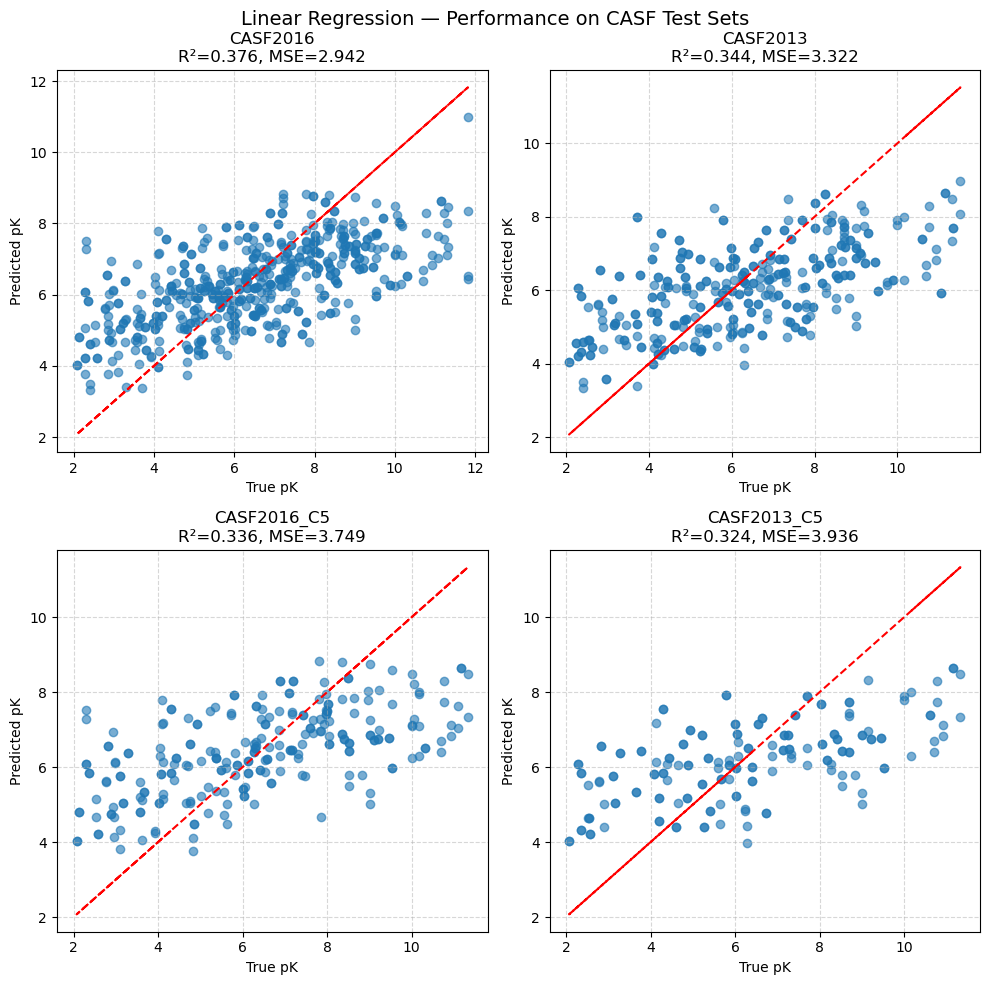

In [9]:
# Model
model = LinearRegression()
model.fit(X_train_orig, y_train_orig)

# Predict an evaluate for all test sets
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, (name, (X_test, y_test)) in zip(axes, test_datasets.items()):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    ax.scatter(y_test, y_pred, alpha=0.6)
    ax.plot(y_test, y_test, color='red', linestyle='--')
    ax.set_title(f"{name.upper()}\nR²={r2:.3f}, MSE={mse:.3f}")
    ax.set_xlabel("True pK")
    ax.set_ylabel("Predicted pK")
    ax.grid(True, linestyle='--', alpha=0.5)

fig.suptitle("Linear Regression — Performance on CASF Test Sets", fontsize=14, y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

- **R-Squared** = A value close to 1  means the model's predictions are very close to the actual data points
- **MSE** = the lower the number to 0, the better

#### **HistGradientBoosting Regression**

C:\Users\ravid\AppData\Local\Temp\ipykernel_17588\4060514447.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


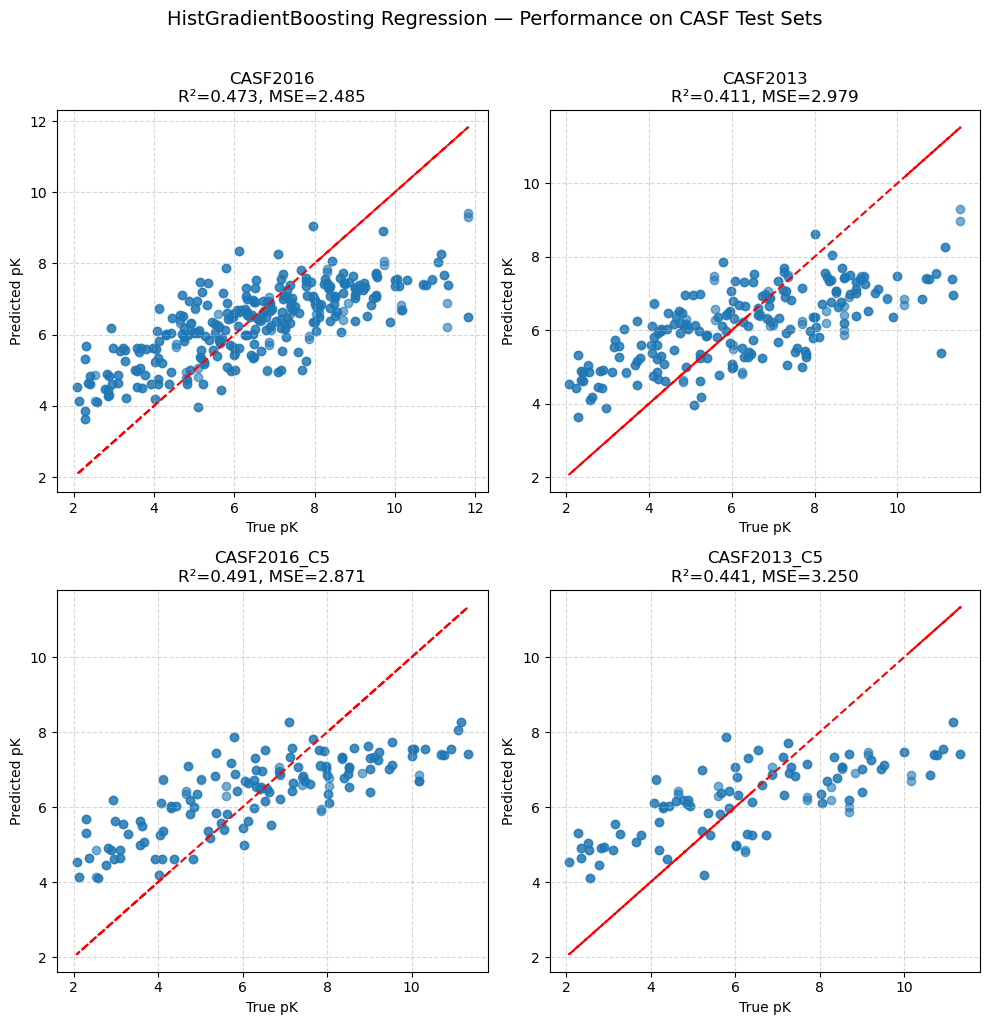

In [ ]:
# Model
hgb_model = HistGradientBoostingRegressor(
    learning_rate=0.01,
    max_iter=300,
    max_depth=6,
    random_state=42
)
hgb_model.fit(X_train_orig, y_train_orig)

# Predict an evaluate for all test sets
fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)
axes = axes.flatten()

for ax, (name, (X_test, y_test)) in zip(axes, test_datasets.items()):
    y_pred = hgb_model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    ax.scatter(y_test, y_pred, alpha=0.6)
    ax.plot(y_test, y_test, color='red', linestyle='--')
    ax.set_title(f"{name.upper()}\nR²={r2:.3f}, MSE={mse:.3f}")
    ax.set_xlabel("True pK")
    ax.set_ylabel("Predicted pK")
    ax.grid(True, linestyle='--', alpha=0.5)

fig.suptitle("HistGradientBoosting Regression — Performance on CASF Test Sets",
             fontsize=14, y=1.02)
plt.show()

#### **XGBoost**

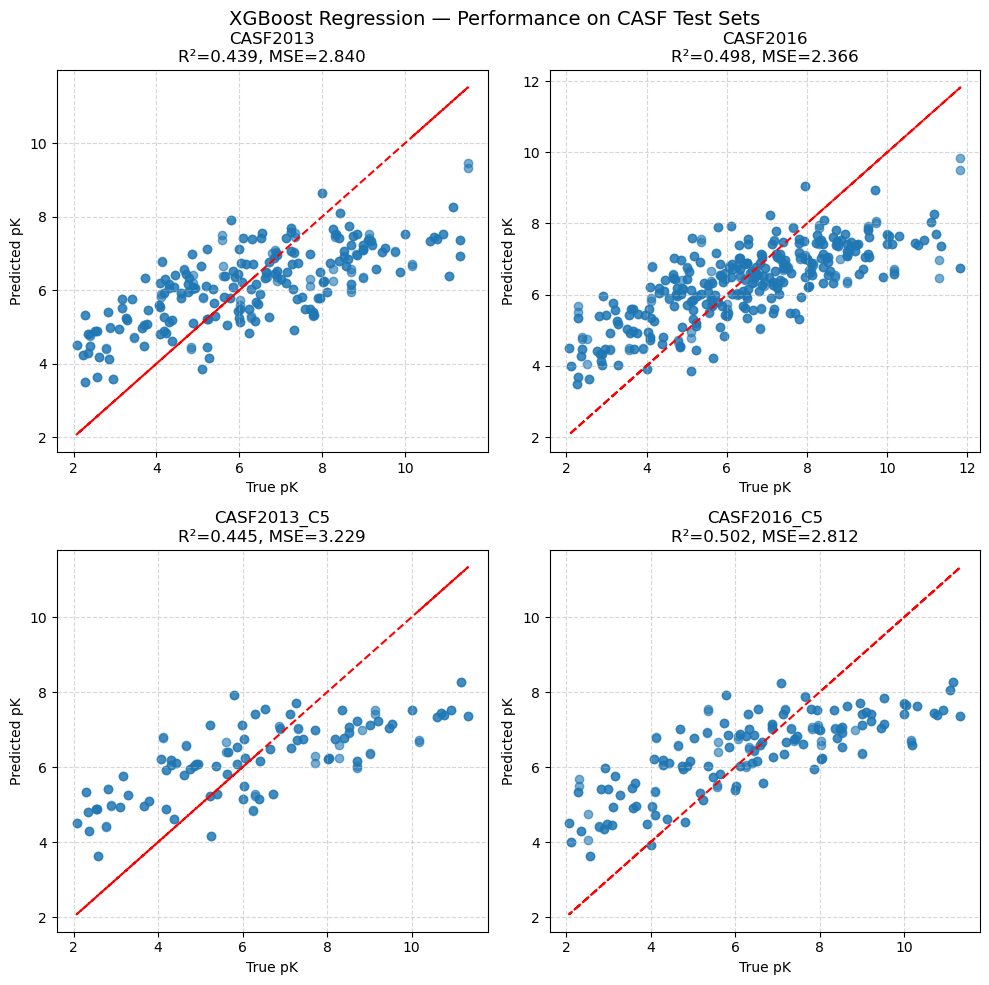

In [ ]:
# Create regression matrices
dtrain = xgb.DMatrix(X_train_orig, label=y_train_orig)
dtest_2013 = xgb.DMatrix(X_test_2013, label=y_test_2013)
dtest_2016 = xgb.DMatrix(X_test_2016, label=y_test_2016)
dtest_2013_c5 = xgb.DMatrix(X_test_2013_c5, label=y_test_2013_c5)
dtest_2016_c5 = xgb.DMatrix(X_test_2016_c5, label=y_test_2016_c5)

datasets = {
    "CASF2013": dtest_2013,
    "CASF2016": dtest_2016,
    "CASF2013_C5": dtest_2013_c5,
    "CASF2016_C5": dtest_2016_c5,
}

# XGBoost parameters
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.01,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'tree_method': 'hist',  
    'device': 'cuda',      # GPU
    'seed': 42
}

# Model
model = xgb.train(params, dtrain, num_boost_round=300)

# Predict an evaluate for all test sets
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, (name, dtest) in zip(axes, datasets.items()):
    y_true = dtest.get_label()
    y_pred = model.predict(dtest)
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)

    ax.scatter(y_true, y_pred, alpha=0.6)
    ax.plot(y_true, y_true, color="red", linestyle="--")
    ax.set_title(f"{name}\nR²={r2:.3f}, MSE={mse:.3f}")
    ax.set_xlabel("True pK")
    ax.set_ylabel("Predicted pK")
    ax.grid(True, linestyle="--", alpha=0.5)

fig.suptitle("XGBoost Regression — Performance on CASF Test Sets", fontsize=14, y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

---

#### **Regression (clean)**

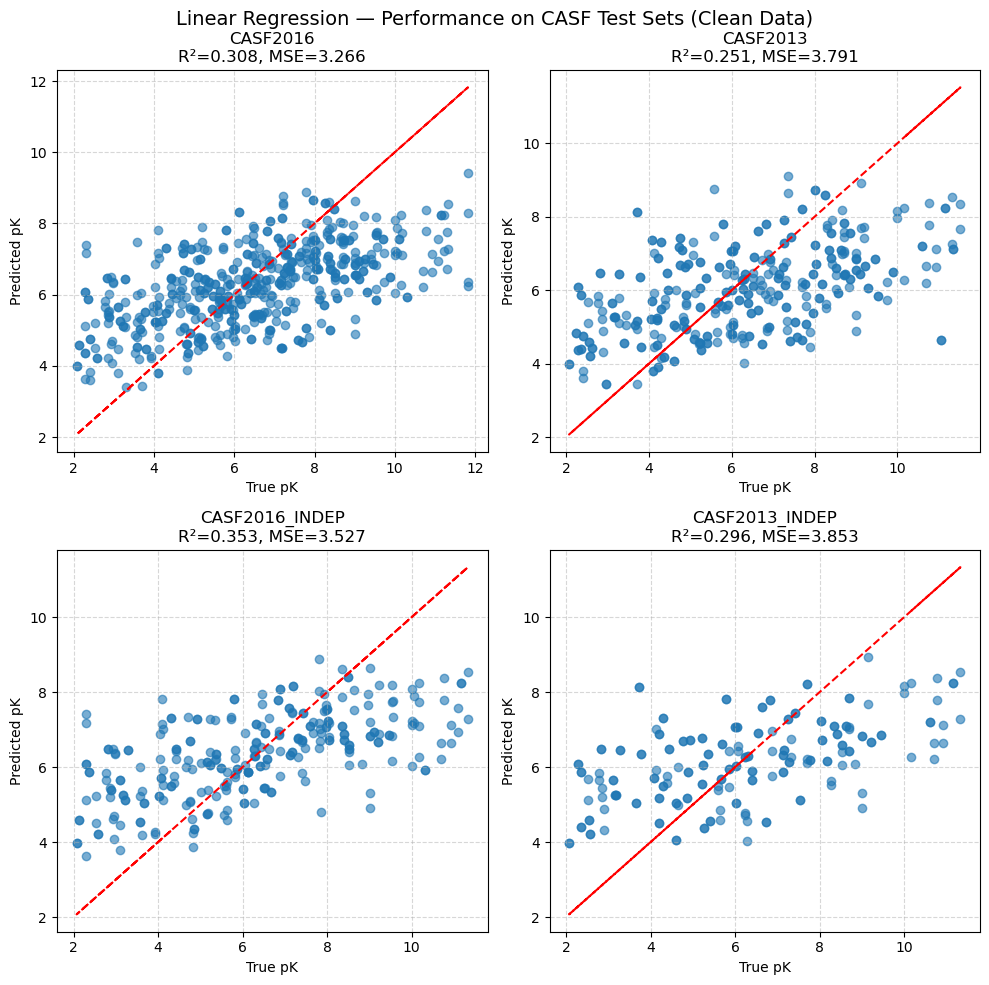

In [12]:
# Model
model_clean = LinearRegression()
model_clean.fit(X_train_clean, y_train_clean)

# Predict and evaluate for all test sets
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, (name, (X_test_clean, y_test_clean)) in zip(axes, test_datasets_clean.items()):
    y_pred = model_clean.predict(X_test_clean)
    r2 = r2_score(y_test_clean, y_pred)
    mse = mean_squared_error(y_test_clean, y_pred)

    ax.scatter(y_test_clean, y_pred, alpha=0.6)
    ax.plot(y_test_clean, y_test_clean, color="red", linestyle="--")
    ax.set_title(f"{name.upper()}\nR²={r2:.3f}, MSE={mse:.3f}")
    ax.set_xlabel("True pK")
    ax.set_ylabel("Predicted pK")
    ax.grid(True, linestyle='--', alpha=0.5)

fig.suptitle("Linear Regression — Performance on CASF Test Sets (Clean Data)", fontsize=14, y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

#### **HistGradientBoosting Regression (clean)**

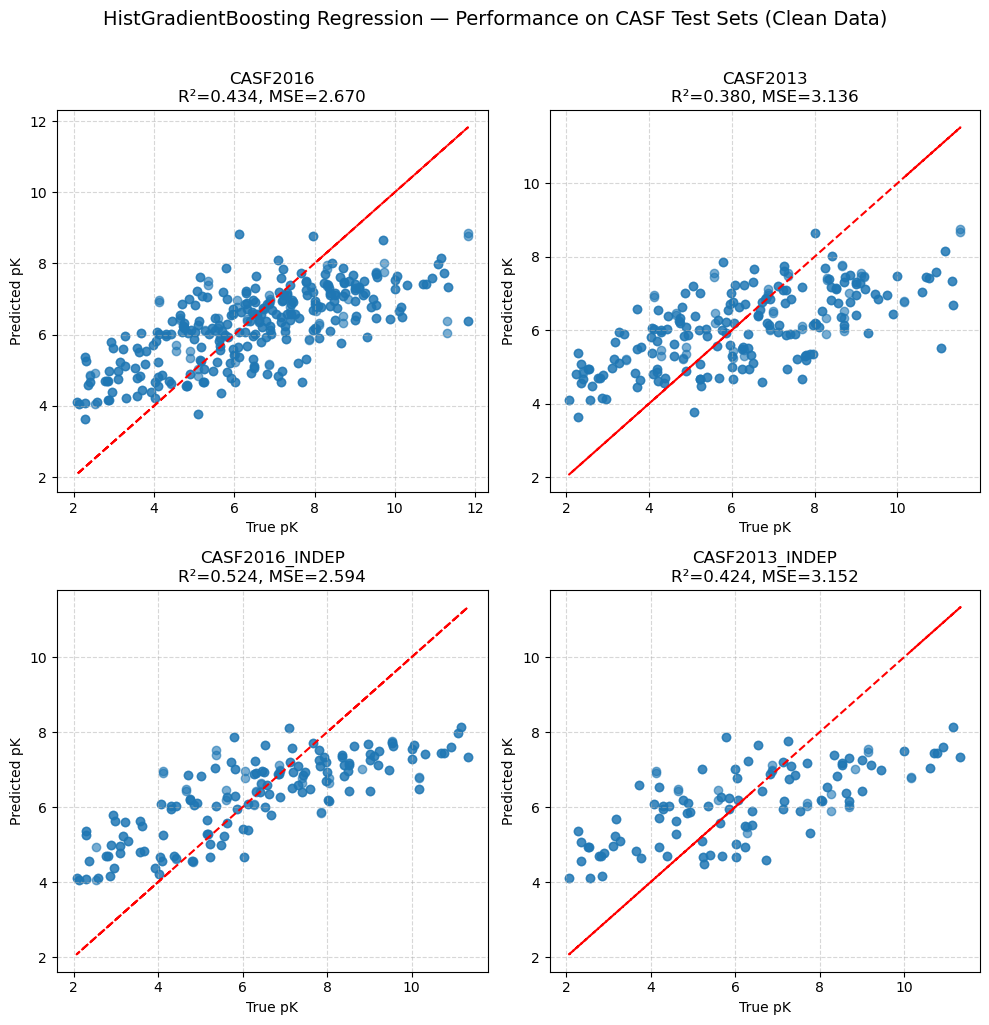

In [13]:
# Model
hgb_model = HistGradientBoostingRegressor(
    learning_rate=0.01,
    max_iter=300,
    max_depth=6,
    random_state=42
)
hgb_model.fit(X_train_clean, y_train_clean)

# Predict an evaluate for all test sets
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, (name, (X_test_clean, y_test_clean)) in zip(axes, test_datasets_clean.items()):
    y_pred = hgb_model.predict(X_test_clean)
    r2 = r2_score(y_test_clean, y_pred)
    mse = mean_squared_error(y_test_clean, y_pred)

    ax.scatter(y_test_clean, y_pred, alpha=0.6)
    ax.plot(y_test_clean, y_test_clean, color="red", linestyle="--")
    ax.set_title(f"{name.upper()}\nR²={r2:.3f}, MSE={mse:.3f}")
    ax.set_xlabel("True pK")
    ax.set_ylabel("Predicted pK")
    ax.grid(True, linestyle='--', alpha=0.5)
fig.suptitle("HistGradientBoosting Regression — Performance on CASF Test Sets (Clean Data)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

#### **XGBoost (clean)**

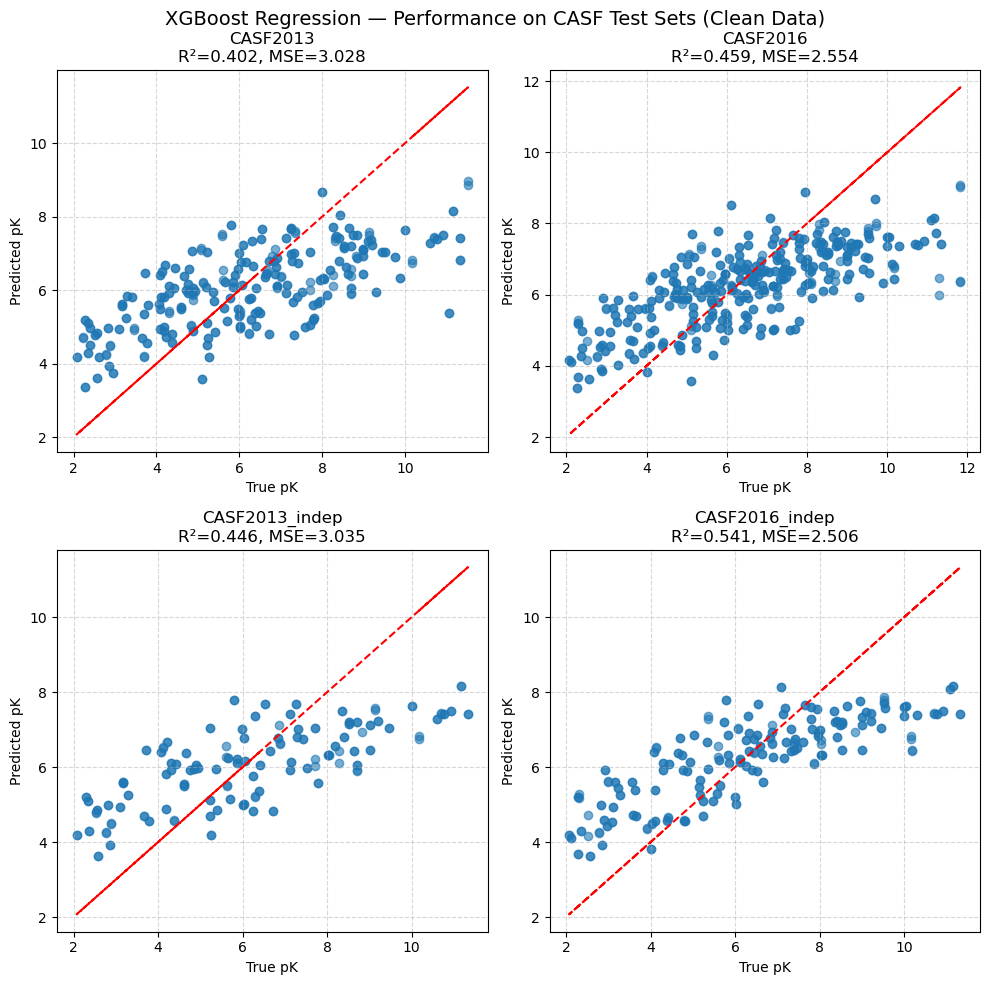

In [14]:
# Create regression matrices
dtrain = xgb.DMatrix(X_train_clean, label=y_train_clean)
dtest_2013 = xgb.DMatrix(X_test_clean_casf2013, label=y_test_clean_casf2013)
dtest_2016 = xgb.DMatrix(X_test_clean_casf2016, label=y_test_clean_casf2016)
dtest_2013_indep = xgb.DMatrix(X_test_clean_casf2013_indep, label=y_test_clean_casf2013_indep)
dtest_2016_indep = xgb.DMatrix(X_test_clean_casf2016_indep, label=y_test_clean_casf2016_indep)

datasets = {
    "CASF2013": dtest_2013,
    "CASF2016": dtest_2016,
    "CASF2013_indep": dtest_2013_indep,
    "CASF2016_indep": dtest_2016_indep,
}

# XGBoost parameters
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'learning_rate': 0.01,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'tree_method': 'hist',  
    'device': 'cuda',      # GPU
    'seed': 42
}

# Model
model = xgb.train(params, dtrain, num_boost_round=300)

# Predict an evaluate for all test sets
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, (name, dtest) in zip(axes, datasets.items()):
    y_true = dtest.get_label()
    y_pred = model.predict(dtest)
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)

    ax.scatter(y_true, y_pred, alpha=0.6)
    ax.plot(y_true, y_true, color="red", linestyle="--")
    ax.set_title(f"{name}\nR²={r2:.3f}, MSE={mse:.3f}")
    ax.set_xlabel("True pK")
    ax.set_ylabel("Predicted pK")
    ax.grid(True, linestyle="--", alpha=0.5)

fig.suptitle("XGBoost Regression — Performance on CASF Test Sets (Clean Data)", fontsize=14, y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()